## IMPORT LIBRARY, READ DATA

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#from matplotlib import dates
#import datetime
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

In [2]:
df=pd.read_csv(r'C:\Users\Danh Bui\Desktop\Resin Consumption Last 1 Month.csv')
df.head(10)

,MOVEMENT_TYPE,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,MATERIAL,MOVEMENT_TYPE,QUANTITY,UNIT_OF_ENTRY,POSTING_DATE,NaN,NaN,NaN
6,M38272,261,27.245,KG,11/14/2022,NaN,NaN,NaN
7,M38272,261,27.245,KG,11/14/2022,NaN,NaN,NaN
8,M38272,261,27.245,KG,11/14/2022,NaN,NaN,NaN
9,M38272,261,27.245,KG,11/14/2022,NaN,NaN,NaN


In [3]:
df=pd.read_csv(r'C:\Users\Danh Bui\Desktop\Resin Consumption Last 1 Month.csv',skiprows=6,usecols=[0,1,2,3,4])
df.head(10)

,MATERIAL,MOVEMENT_TYPE,QUANTITY,UNIT_OF_ENTRY,POSTING_DATE
0,M38272,261,27.245,KG,11/14/2022
1,M38272,261,27.245,KG,11/14/2022
2,M38272,261,27.245,KG,11/14/2022
3,M38272,261,27.245,KG,11/14/2022
4,M38272,261,24.089,KG,11/14/2022
5,M38272,261,12.423,KG,11/14/2022
6,M40443,261,18.347,KG,11/14/2022
7,M38272,261,13.070,KG,11/14/2022
8,M33469,261,5.368,KG,11/14/2022
9,M38272,261,22.777,KG,11/18/2022


In [6]:
df['QUANTITY'].describe()

count    49473.000000
mean        55.941045
std        857.545786
min        -20.498000
25%         10.194000
50%         18.347000
75%         29.075000
max      54949.000000
Name: QUANTITY, dtype: float64

In [7]:
df.sort_values(by=['QUANTITY'])

,MATERIAL,MOVEMENT_TYPE,QUANTITY,UNIT_OF_ENTRY,POSTING_DATE
347,M38272,261,-20.498,KG,11/18/2022
4048,M27839,261,0.006,KG,11/13/2022
3528,M33469,261,0.010,KG,11/12/2022
17643,M40443,261,0.089,KG,12/1/2022
5139,M38272,261,0.107,KG,11/1/2022
...,...,...,...,...,...
17924,M41908,102,25500.000,KG,12/10/2022
10942,M41908,101,25500.000,KG,12/12/2022
22535,M40443,102,44000.000,KG,11/22/2022
22532,M40443,101,44000.000,KG,11/22/2022


In [8]:
df[df['QUANTITY']==20.498]

,MATERIAL,MOVEMENT_TYPE,QUANTITY,UNIT_OF_ENTRY,POSTING_DATE
91,M38272,261,20.498,KG,11/15/2022
131,M38272,261,20.498,KG,11/17/2022
487,M38272,261,20.498,KG,11/23/2022
967,M38272,261,20.498,KG,11/10/2022
1222,M38272,261,20.498,KG,11/10/2022
...,...,...,...,...,...
48156,M38272,261,20.498,KG,11/3/2022
48159,M38272,261,20.498,KG,11/3/2022
48471,M38272,261,20.498,KG,11/3/2022
48699,M38272,261,20.498,KG,11/3/2022


In [9]:
df = df.replace(-20.498,20.498)
df['QUANTITY'].describe()
#df['POSTING_DATE'] = pd.to_datetime(df['POSTING_DATE'])

count    49473.000000
mean        55.941873
std        857.545732
min          0.006000
25%         10.194000
50%         18.347000
75%         29.075000
max      54949.000000
Name: QUANTITY, dtype: float64

## VISUALIZE DATA

In [10]:
pivot_table=pd.pivot_table(df,values='QUANTITY',index=['MATERIAL'],
                    columns=['MOVEMENT_TYPE',],aggfunc=np.sum,fill_value=0)
pivot_table=pivot_table.round().astype('int64')
pivot_table

MOVEMENT_TYPE,101,102,261,262,711,712
MATERIAL,,,,,,
M21165,99000,0,82228,157,0,670
M27839,50000,0,56639,50,0,1970
M31520,16000,0,87488,317,3600,2493
M31595,0,0,2736,0,0,323
M33469,19500,0,10027,36,2200,1991
M38272,681992,0,625031,1273,28403,21483
M40443,330000,66000,176650,360,0,2065
M41908,76500,25500,52224,106,1193,1009
M43203,132000,0,97412,239,4745,6003


In [11]:
pivot_table2=pivot_table.transpose()

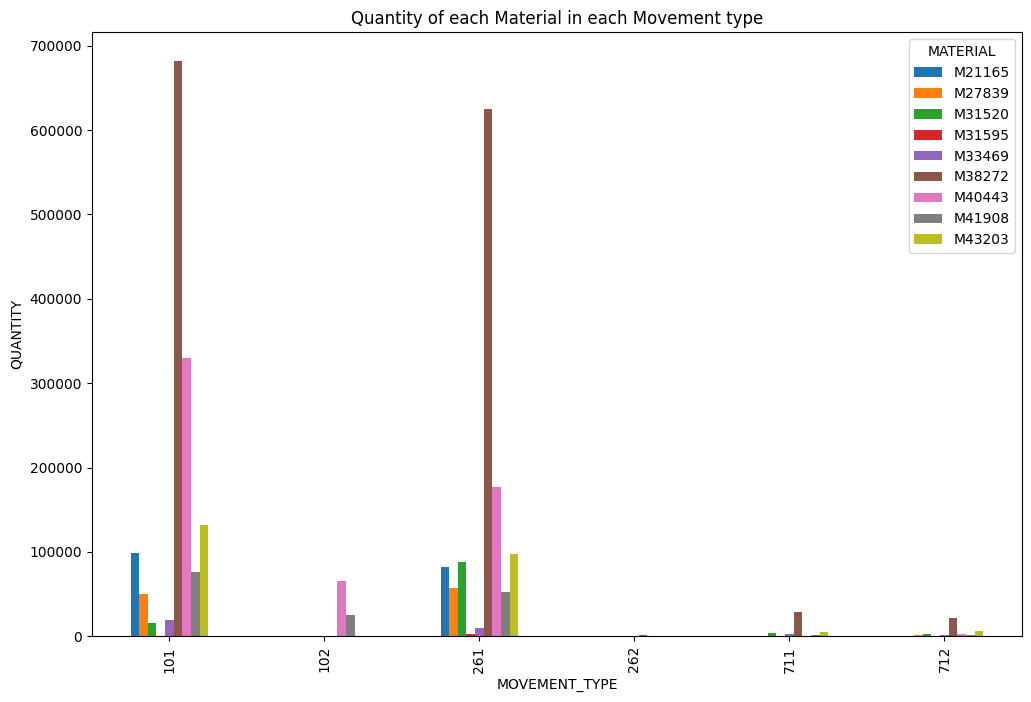

In [12]:
ax = pivot_table.T.plot(kind='bar', ylabel='QUANTITY', title='Quantity of each Material in each Movement type')

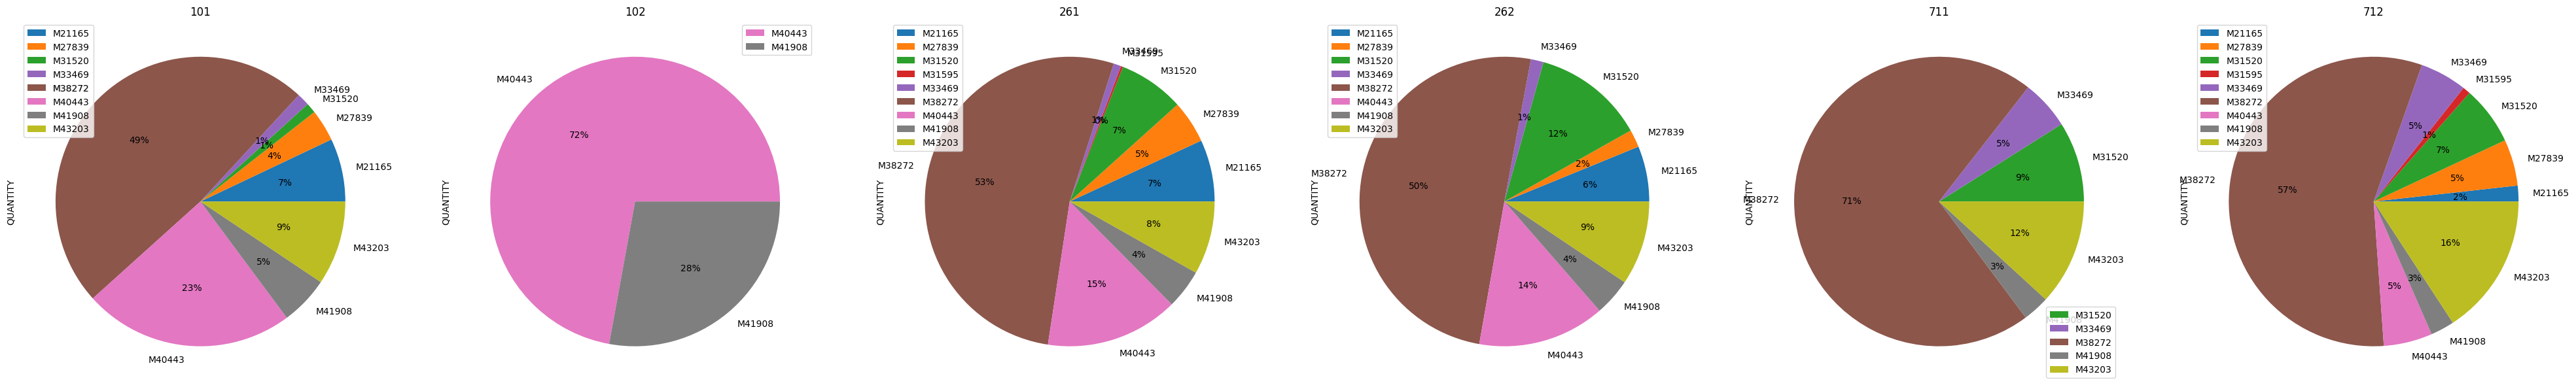

In [13]:
ax2 = pivot_table2.T.plot(kind='pie', ylabel='QUANTITY',subplots=True, figsize=(50, 50), autopct=lambda p: '{:.0f}%'.format(round(p)) if p > 0 else '', title=pivot_table2.index.tolist())

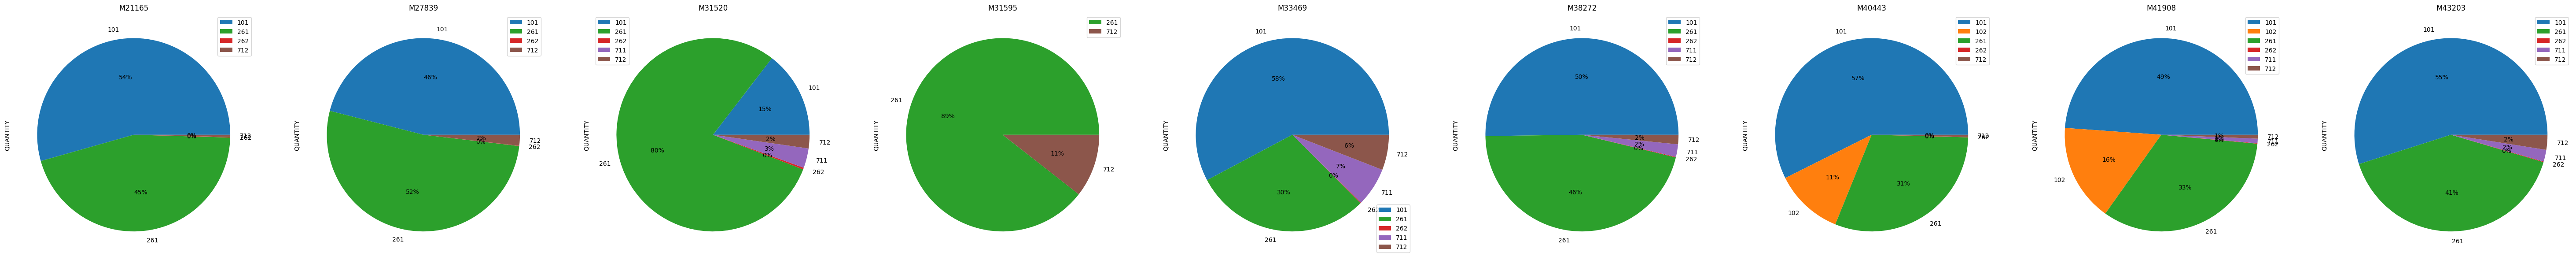

In [14]:
ax2 = pivot_table.T.plot(kind='pie', ylabel='QUANTITY',subplots=True, figsize=(75, 75), autopct=lambda p: '{:.0f}%'.format(round(p)) if p > 0 else '', title=pivot_table.index.tolist())

In [15]:
result = df.groupby(['MATERIAL','MOVEMENT_TYPE','POSTING_DATE']).sum()

<AxesSubplot:title={'center':'Goods receive from 11/1 to 12/13'}, xlabel='POSTING_DATE', ylabel='KG'>

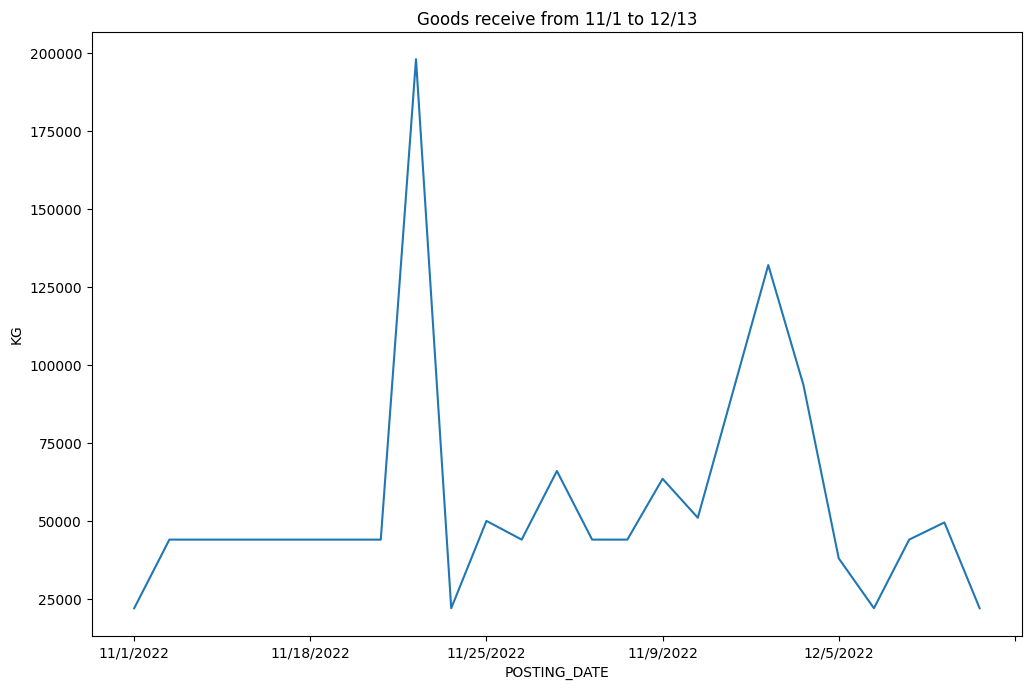

In [16]:
df[df['MOVEMENT_TYPE']==101].groupby(['POSTING_DATE']).sum()['QUANTITY'].plot(title='Goods receive from 11/1 to 12/13',ylabel='KG')
#plt.gcf().autofmt_xdate()

In [17]:
df[df['MOVEMENT_TYPE']==101].groupby(['POSTING_DATE']).sum()['QUANTITY'].nlargest(3)

POSTING_DATE
11/22/2022    198000.0
12/13/2022    132000.0
12/2/2022      93500.0
Name: QUANTITY, dtype: float64

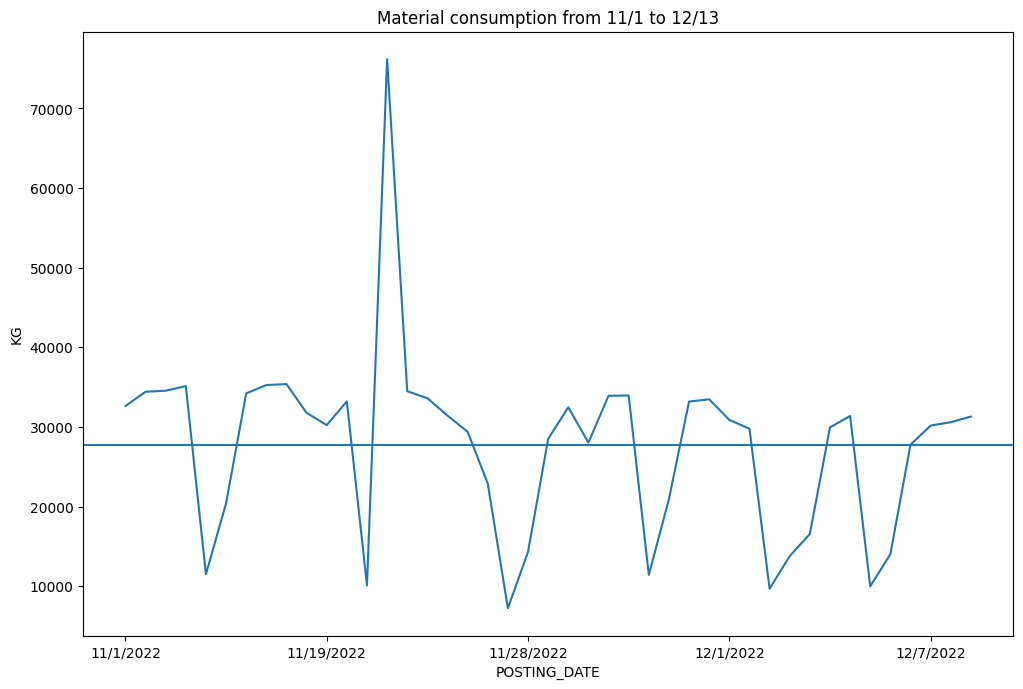

In [18]:
df[df['MOVEMENT_TYPE']==261].groupby(['POSTING_DATE']).sum()['QUANTITY'].plot(title='Material consumption from 11/1 to 12/13',ylabel='KG')
plt.axhline(y=np.mean(df[df['MOVEMENT_TYPE']==261].groupby(['POSTING_DATE']).sum()['QUANTITY']))

In [19]:
df[df['MOVEMENT_TYPE']==261].groupby(['POSTING_DATE']).sum()['QUANTITY'].nlargest(1)

POSTING_DATE
11/21/2022    76193.823
Name: QUANTITY, dtype: float64

<AxesSubplot:title={'center':'Undo of 261 from 11/1 to 12/13'}, xlabel='POSTING_DATE', ylabel='KG'>

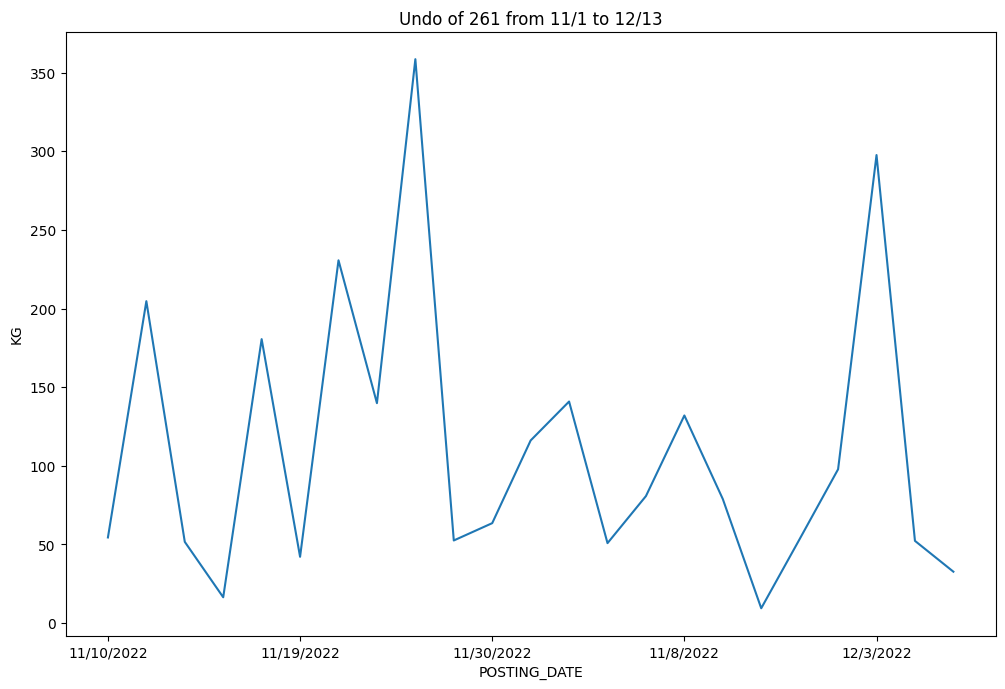

In [20]:
df[df['MOVEMENT_TYPE']==262].groupby(['POSTING_DATE']).sum()['QUANTITY'].plot(title='Undo of 261 from 11/1 to 12/13',ylabel='KG')

In [21]:
df[df['MOVEMENT_TYPE']==262].groupby(['POSTING_DATE']).sum()['QUANTITY'].nlargest(2)

POSTING_DATE
11/26/2022    358.632
12/3/2022     297.660
Name: QUANTITY, dtype: float64

## CREATE USEFUL TABLE

In [22]:
pivot_table.columns.name = None
pivot_table.reset_index()

,MATERIAL,101,102,261,262,711,712
0,M21165,99000,0,82228,157,0,670
1,M27839,50000,0,56639,50,0,1970
2,M31520,16000,0,87488,317,3600,2493
3,M31595,0,0,2736,0,0,323
4,M33469,19500,0,10027,36,2200,1991
5,M38272,681992,0,625031,1273,28403,21483
6,M40443,330000,66000,176650,360,0,2065
7,M41908,76500,25500,52224,106,1193,1009
8,M43203,132000,0,97412,239,4745,6003


In [23]:
inventory_balancing = pivot_table.reset_index()[['MATERIAL']].copy()
inventory_balancing['NET_INVENTORY']=pivot_table.reset_index()[101]-pivot_table.reset_index()[102]-pivot_table.reset_index()[261]+pivot_table.reset_index()[262]-pivot_table.reset_index()[711]+pivot_table.reset_index()[712]
inventory_balancing

,MATERIAL,NET_INVENTORY
0,M21165,17599
1,M27839,-4619
2,M31520,-72278
3,M31595,-2413
4,M33469,9300
5,M38272,51314
6,M40443,89775
7,M41908,-1302
8,M43203,36085


In [24]:
quality_control = pivot_table.reset_index()[['MATERIAL']].copy()
quality_control['RETURN_MATERIAL_RATE']=(pivot_table.reset_index()[102]/pivot_table.reset_index()[101]*100).round(2).fillna(0)
quality_control['OVERESTIMATE_MATERIAL_RATE']=(pivot_table.reset_index()[262]/pivot_table.reset_index()[261]*100).round(2).fillna(0)
quality_control['LOSS_MATERIAL_RATE']=(pivot_table.reset_index()[711]/pivot_table.reset_index()[261]*100).round(2).fillna(0)
quality_control

,MATERIAL,RETURN_MATERIAL_RATE,OVERESTIMATE_MATERIAL_RATE,LOSS_MATERIAL_RATE
0,M21165,0.00,0.19,0.00
1,M27839,0.00,0.09,0.00
2,M31520,0.00,0.36,4.11
3,M31595,0.00,0.00,0.00
4,M33469,0.00,0.36,21.94
5,M38272,0.00,0.20,4.54
6,M40443,20.00,0.20,0.00
7,M41908,33.33,0.20,2.28
8,M43203,0.00,0.25,4.87


In [25]:
df_711=df[df['MOVEMENT_TYPE']==711].groupby(['MATERIAL','POSTING_DATE']).sum()['QUANTITY'].reset_index()
df_711

,MATERIAL,POSTING_DATE,QUANTITY
0,M31520,11/27/2022,3600.000
1,M33469,11/27/2022,2200.000
2,M38272,11/27/2022,28402.901
3,M41908,11/27/2022,1192.586
4,M43203,11/27/2022,4744.557


In [26]:
df_712=df[df['MOVEMENT_TYPE']==712].groupby(['MATERIAL','POSTING_DATE']).sum()['QUANTITY'].reset_index()
df_712

,MATERIAL,POSTING_DATE,QUANTITY
0,M21165,11/27/2022,670.460
1,M27839,11/27/2022,1969.874
2,M31520,11/27/2022,2493.466
3,M31595,11/27/2022,322.696
4,M33469,11/27/2022,1990.980
5,M38272,11/27/2022,21482.757
6,M40443,11/27/2022,2065.473
7,M41908,11/27/2022,1008.853
8,M43203,11/27/2022,6002.977


In [27]:
df_700 = pd.merge(df_711.drop(columns='POSTING_DATE'),df_712.drop(columns='POSTING_DATE'), on='MATERIAL', how='outer')
df_700

,MATERIAL,QUANTITY_x,QUANTITY_y
0,M31520,3600.000,2493.466
1,M33469,2200.000,1990.980
2,M38272,28402.901,21482.757
3,M41908,1192.586,1008.853
4,M43203,4744.557,6002.977
5,M21165,NaN,670.460
6,M27839,NaN,1969.874
7,M31595,NaN,322.696
8,M40443,NaN,2065.473


In [28]:
df_700.rename(columns = {'QUANTITY_x':711, 'QUANTITY_y':712}, inplace = True)
df_700[711]=df_700[711].fillna(0)
df_700

,MATERIAL,711,712
0,M31520,3600.000,2493.466
1,M33469,2200.000,1990.980
2,M38272,28402.901,21482.757
3,M41908,1192.586,1008.853
4,M43203,4744.557,6002.977
5,M21165,0.000,670.460
6,M27839,0.000,1969.874
7,M31595,0.000,322.696
8,M40443,0.000,2065.473


In [29]:
df_700['LOSS_AFTER_712']=df_700[711]-df_700[712]
df_700

,MATERIAL,711,712,LOSS_AFTER_712
0,M31520,3600.000,2493.466,1106.534
1,M33469,2200.000,1990.980,209.020
2,M38272,28402.901,21482.757,6920.144
3,M41908,1192.586,1008.853,183.733
4,M43203,4744.557,6002.977,-1258.420
5,M21165,0.000,670.460,-670.460
6,M27839,0.000,1969.874,-1969.874
7,M31595,0.000,322.696,-322.696
8,M40443,0.000,2065.473,-2065.473


## CONCLUSION SUGGESTION

In [30]:
summarize_material = pd.DataFrame({
    "MATERIAL":["M21165","M27839","M31520","M31595","M33469","M38272","M40443","M41908","M43203"],
    "DESCRIPTION":["minor material, inventory +17599kg","minor material, inventory -4619kg","minor material,inv-72278kg,still loss 1106kg","minor material, inventory -2413kg","minor material,inv+9300kg,22% loss rate","main material,inv+51314kg,still loss 6920kg","main material,inv+89775kg,20%returning rate","minor material,inv-1302kg,33% returning rate","minor material, inventory +36085kg"]
})

In [31]:
summarize_material

,MATERIAL,DESCRIPTION
0,M21165,"minor material, inventory +17599kg"
1,M27839,"minor material, inventory -4619kg"
2,M31520,"minor material,inv-72278kg,still loss 1106kg"
3,M31595,"minor material, inventory -2413kg"
4,M33469,"minor material,inv+9300kg,22% loss rate"
5,M38272,"main material,inv+51314kg,still loss 6920kg"
6,M40443,"main material,inv+89775kg,20%returning rate"
7,M41908,"minor material,inv-1302kg,33% returning rate"
8,M43203,"minor material, inventory +36085kg"


#### ngày 22/11 nhập kho cao ngất ngưởng, gấp 2 lần trung bình
#### ngày 21/11 sản xuất cao bất thường, gấp 2.6 lần trung bình
#### ngày 26/11 undo nhiều, prod plan check
#### ngày 27/11 mất hàng, tìm lại được --> tìm hiểu lí do, rút kinh nghiệm